In [1]:
library(ArchR)
library(BSgenome.Hsapiens.UCSC.hg38)
set.seed(1)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
suppressPackageStartupMessages({
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(tidyr)
    library(purrr)
    library(data.table)
    library(reticulate)
    # plan("multicore", workers = 12)
    # options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [3]:
addArchRThreads(threads = 32) 
addArchRGenome("hg38")

Setting default number of Parallel threads to 32.

Setting default genome to Hg38.



### Load DMG atlas ATAC (matching Signac filtered cells)

In [4]:
dmg_atlas <- loadArchRProject('./ArchRSubset/')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [5]:
use_condaenv('multi_integration')

In [6]:
sc <- import("scanpy")
adata <- sc$read_h5ad("../mosaic_integration_scglue/dmg_atlas_atac_full_PEAKS_v3.h5ad")
adata

AnnData object with n_obs × n_vars = 124594 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paire

In [7]:
meta <- adata$obs

# Access the cellnames
cell_names <- rownames(meta)

# Define the pattern and replacement
pattern <- "(.*)_(.*)$"
replacement <- "\\1#\\2"

# Apply the pattern and replacement using sub
rownames(meta) <- sub(pattern, replacement, cell_names)

meta$cell_names <- rownames(meta)
# Subset the DataFrame to include only rows with cell names in dmg_atlas$cellNames
meta <- meta[meta$cell_names %in% dmg_atlas$cellNames, ]
meta

,total,duplicate,chimeric,unmapped,lowmapq,mitochondrial,nonprimary,passed_filters,is__cell_barcode,excluded_reason,⋯,atac_dup_reads,atac_chimeric_reads,atac_mitochondrial_reads,atac_TSS_fragments,atac_peak_region_fragments,atac_peak_region_cutsites,batch,n_counts,MP,cell_names
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<fct>,<chr>
atac_T19-91014#AAACGAAAGACCCTAT-1,37892,15065,1,438,3127,45,5,19211,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,17618.04,RGLike,atac_T19-91014#AAACGAAAGACCCTAT-1
atac_T19-91014#AAACGAAAGCGTTGCC-1,22601,6146,0,246,1761,1,3,14444,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,20374.66,C1Q,atac_T19-91014#AAACGAAAGCGTTGCC-1
atac_T19-91014#AAACGAAAGTGAATAC-1,21580,5723,1,213,2597,9,12,13025,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,18186.32,Oligodendrocyte,atac_T19-91014#AAACGAAAGTGAATAC-1
atac_T19-91014#AAACGAAAGTGCCCTG-1,28527,7851,0,319,2382,16,6,17953,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,20114.19,C1Q,atac_T19-91014#AAACGAAAGTGCCCTG-1
atac_T19-91014#AAACGAAAGTGTAATG-1,27213,9888,2,323,2030,71,9,14890,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,18916.68,RGLike,atac_T19-91014#AAACGAAAGTGTAATG-1
atac_T19-91014#AAACGAACAAATGCTC-1,32533,8763,0,352,2536,206,14,20662,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,22488.16,ACLike,atac_T19-91014#AAACGAACAAATGCTC-1
atac_T19-91014#AAACGAACACGCCGAT-1,17835,5161,3,213,1943,74,16,10425,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,16520.19,RGLike,atac_T19-91014#AAACGAACACGCCGAT-1
atac_T19-91014#AAACGAACAGGTGTCC-1,23349,5489,2,242,1534,40,5,16037,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,20977.60,IL1B,atac_T19-91014#AAACGAACAGGTGTCC-1
atac_T19-91014#AAACGAAGTACGGAGT-1,66244,12557,6,786,6822,55,33,45985,1,0,⋯,NaN,NaN,NaN,NaN,NaN,NaN,0,25071.23,RGLike,atac_T19-91014#AAACGAAGTACGGAGT-1


In [8]:
table(meta$MP)


         ACLike       Astrocyte             C1Q         COPLike       CiliaLike 
           6957            2894            4252            6074            1927 
    Endothelial          GBlike          GWLike     Homeostatic            IL1B 
            684            3205            3947            1139            1073 
        IPCLike      LipidLaden        Lymphoid  MonoNeutrophil           Mural 
           3887            1611             856            2785             898 
         Neuron             OPC         OPCLike Oligodendrocyte          RGLike 
           2632            2548           18892           15321            8967 
      Scavenger          TDLike      TriIPCLike 
           3346           28077            1988 

In [9]:
meta$MP <- recode(meta$MP, 
                  'RGLike' = 'C1_RGLike', 
                  'TriIPCLike' = 'C2_TriIPCLike',
                  'IPCLike' = 'C3_IPCLike',
                  'OPCLike' = 'C4_OPCLike',
                  'COPLike' = 'C5_COPLike',
                  'ACLike' = 'C6_ACLike',
                  'CiliaLike' = 'C7_CiliaLike',
                  'GBlike' = 'C10_GBLike',
                  'TDLike' = 'C8_TDLike',
                  'GWLike' = 'C9_GWLike',
                  'Oligodendrocyte' = 'C11_Oligodendrocyte',
                  'OPC' = 'C12_OPC',
                  'Astrocyte' = 'C13_Astrocyte',
                  'Neuron' = 'C14_Neuron',
                  'MonoNeutrophil' = 'C15_MonoNeutrophil',
                  'C1Q' = 'C16_C1Q',
                  'LipidLaden' = 'C17_LipidLaden',
                  'Scavenger' = 'C18_Scavenger',
                  'IL1B' = 'C19_IL1B',
                  'Homeostatic' = 'C20_Homeostatic',
                  'Lymphoid' = 'C21_Lymphoid',
                  'Endothelial' = 'C22_Endothelial',
                  'Mural' = 'C23_Mural')

In [10]:
dmg_atlas <- addCellColData(ArchRProj = dmg_atlas, data = as.character(meta$MP),
    cells = rownames(meta), name = "MP", force = TRUE)
dmg_atlas

Overriding previous entry for MP


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/archr/ArchRSubset 
samples(21): atac_T20-90296 atac_T19-91014 ... atac_P-2687_S-2688
  atac_P-6255_S-8500
sampleColData names(1): ArrowFiles
cellColData names(21): Sample TSSEnrichment ... FRIP MPv2
numberOfCells(1): 123960
medianTSS(1): 8.384
medianFrags(1): 11181

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3aed7a7162d504-Date-2024-09-09_Time-21-11-33.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 
Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3aed7a7162d504-Date-2024-09-09_Time-21-11-33.log



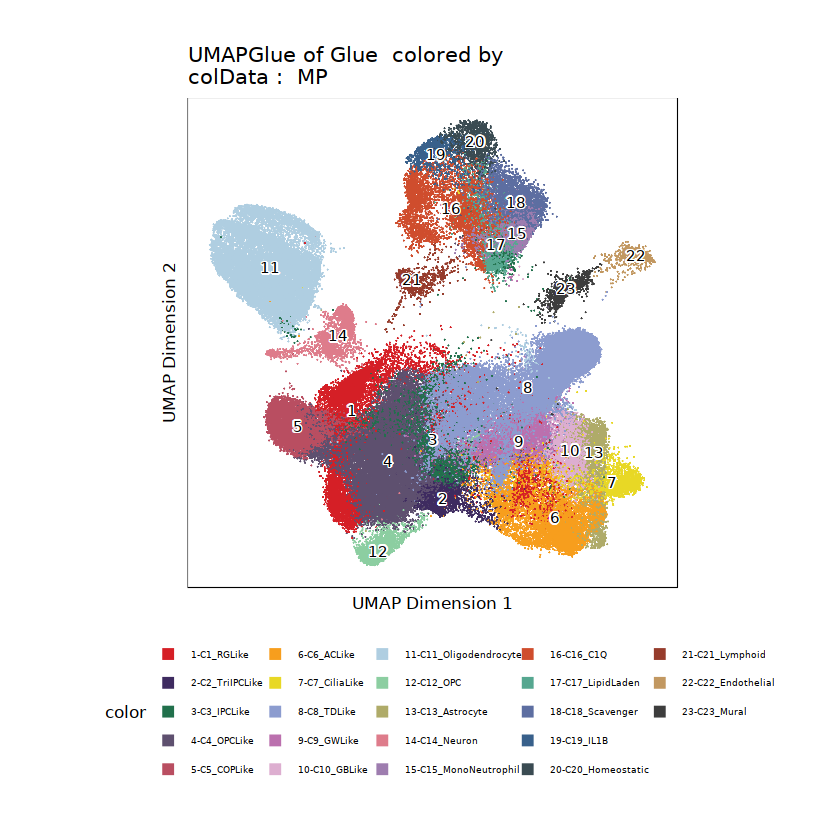

In [11]:
p1 <- plotEmbedding(
    dmg_atlas, 
    colorBy = "cellColData", 
    name = "MP", 
     embedding = "UMAPGlue"
)
p1

In [12]:
library(BSgenome.Hsapiens.UCSC.hg38)
dmg_atlas <- addGroupCoverages(ArchRProj = dmg_atlas, groupBy = "MP", force=TRUE)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-3aed7a5eaac303-Date-2024-09-09_Time-21-11-48.log
If there is an issue, please report to github with logFile!

C1_RGLike (1 of 23) : CellGroups N = 5

C2_TriIPCLike (2 of 23) : CellGroups N = 5

C3_IPCLike (3 of 23) : CellGroups N = 5

C4_OPCLike (4 of 23) : CellGroups N = 5

C5_COPLike (5 of 23) : CellGroups N = 3

C6_ACLike (6 of 23) : CellGroups N = 5

C7_CiliaLike (7 of 23) : CellGroups N = 4

C8_TDLike (8 of 23) : CellGroups N = 5

C9_GWLike (9 of 23) : CellGroups N = 5

C10_GBLike (10 of 23) : CellGroups N = 5

C11_Oligodendrocyte (11 of 23) : CellGroups N = 5

C12_OPC (12 of 23) : CellGroups N = 5

C13_Astrocyte (13 of 23) : CellGroups N = 5

C14_Neuron (14 of 23) : CellGroups N = 5

C15_MonoNeutrophil (15 of 23) : CellGroups N = 5

C16_C1Q (16 of 23) : CellGroups N = 5

C17_LipidLaden (17 of 23) : CellGroups N = 5

C18_Scavenger (18 of 23) : CellGroups N = 5

C19_IL1B (19 of 23) : CellGroups N = 5

C20_Homeostatic (20 of 23) :

In [13]:
pathToMacs2 <- '/home/cruiz2/miniconda3/envs/python2/bin/macs2'

In [14]:
dmg_atlas <- addReproduciblePeakSet(
    ArchRProj = dmg_atlas, 
    groupBy = "MP", 
    pathToMacs2 = pathToMacs2,
    force=TRUE
)

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-3aed7a69029433-Date-2024-09-09_Time-21-49-05.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2024-09-09 21:49:06 : Peak Calling Parameters!, 0.004 mins elapsed.



                                  Group nCells nCellsUsed nReplicates nMin nMax
C1_RGLike                     C1_RGLike   8967       2076           5  193  500
C2_TriIPCLike             C2_TriIPCLike   1988       1176           5   50  500
C3_IPCLike                   C3_IPCLike   3887       1888           5  297  500
C4_OPCLike                   C4_OPCLike  18892       2500           5  500  500
C5_COPLike                   C5_COPLike   6074        835           3  138  500
C6_ACLike                     C6_ACLike   6957       2463           5  463  500
C7_CiliaLike               C7_CiliaLike   1927        748           4   66  500
C8_TDLike                     C8_TDLike  28077       2413           5  413  500
C9_GWLike                     C9_GWLike   3947       1454           5  121  500
C10_GBLike                   C10_GBLike   3205       1910           5  180  500
C11_Oligodendrocyte C11_Oligodendrocyte  15321       2500           5  500  500
C12_OPC                         C12_OPC 

2024-09-09 21:49:06 : Batching Peak Calls!, 0.004 mins elapsed.

2024-09-09 21:49:06 : Batch Execution w/ safelapply!, 0 mins elapsed.

2024-09-09 21:52:15 : Identifying Reproducible Peaks!, 3.167 mins elapsed.

2024-09-09 21:52:46 : Creating Union Peak Set!, 3.676 mins elapsed.

Converged after 13 iterations!

Plotting Ggplot!

2024-09-09 21:53:09 : Finished Creating Union Peak Set (558767)!, 4.066 mins elapsed.



In [15]:
dmg_atlas <- addPeakMatrix(dmg_atlas, force=TRUE)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-3aed7a7a57ba4e-Date-2024-09-09_Time-21-53-09.log
If there is an issue, please report to github with logFile!

2024-09-09 21:53:09 : Batch Execution w/ safelapply!, 0 mins elapsed.

Overriding previous entry for ReadsInPeaks

Overriding previous entry for FRIP

ArchR logging successful to : ArchRLogs/ArchR-addPeakMatrix-3aed7a7a57ba4e-Date-2024-09-09_Time-21-53-09.log



In [16]:
sc <- import("scanpy")
adata <- sc$read_h5ad("../mosaic_integration_scglue/dmg_atac_emb_malignant_full_PEAKS.h5ad")
adata

AnnData object with n_obs × n_vars = 84494 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired

In [17]:
# Access the cellnames
cell_names <- adata$obs_names$to_list()

# Define the pattern and replacement
pattern <- "(.*)_(.*)$"
replacement <- "\\1#\\2"

# Apply the pattern and replacement using sub
cell_names <- sub(pattern, replacement, cell_names)
head(cell_names)
tail(cell_names)

[1] "atac_T19-91014#AAACGAAAGACCCTAT-1" "atac_T19-91014#AAACGAAAGTGTAATG-1"
[3] "atac_T19-91014#AAACGAACAAATGCTC-1" "atac_T19-91014#AAACGAACACGCCGAT-1"
[5] "atac_T19-91014#AAACGAAGTACGGAGT-1" "atac_T19-91014#AAACGAAGTATCCCTC-1"

[1] "multiome_P-6774_S-10146#TTTGTGGCATTATGAC-1"
[2] "multiome_P-6774_S-10146#TTTGTGTTCCTAGTAA-1"
[3] "multiome_P-6774_S-10146#TTTGTTGGTAGGATTT-1"
[4] "multiome_P-6774_S-10146#TTTGTTGGTTGGATAT-1"
[5] "multiome_P-6774_S-10146#TTTGTTGGTTGTAACG-1"
[6] "multiome_P-6774_S-10146#TTTGTTGGTTTATCGC-1"

In [18]:
idx <- BiocGenerics::which(dmg_atlas$cellNames %in% cell_names)
head(idx)
length(idx)

[1] 1 2 3 4 5 6

[1] 83921

In [19]:
cellsAtlas <- dmg_atlas$cellNames[idx]
head(cellsAtlas)

[1] "atac_MUV1#CCCTAACCATGGAGGT-1" "atac_MUV1#GGGTCTGTCGGAGTTT-1"
[3] "atac_MUV1#GTGTCCTGTGAGTCGA-1" "atac_MUV1#AGCTGATCATGTATCG-1"
[5] "atac_MUV1#GTGTCAAGTATCGCGC-1" "atac_MUV1#CAAAGCTCAGCGTGAA-1"

In [20]:
length(cellsAtlas)

[1] 83921

In [21]:
# to avoid any errors (Error in .Call2("map_positions", run_lens, pos, method, PACKAGE = "S4Vectors"): subscript contains NAs)
# the exact name of cells must be inside the archr object
# addditonal cell names will lead to the error above 
# also see https://github.com/GreenleafLab/ArchR/issues/212

malignant <- subsetArchRProject(
  ArchRProj = dmg_atlas,
  cells = cellsAtlas,
  outputDirectory = "ArchR_malignant_FINAL",
  dropCells = TRUE,
  logFile = NULL,
  force = FALSE
)

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!

Copying ArchRProject to new outputDirectory : /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/archr/ArchR_malignant_FINAL

Copying Arrow Files...

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 9): Annotations

Copying Other Files (2 of 9): Background-Peaks.rds

Copying Other Files (3 of 9): Embeddings

Copying Other Files (4 of 9): GroupCoverages

Copying Other Files (5 of 9): IterativeLSI

Copying Other Files (6 of 9): Peak2GeneLinks

Copying Other Files (7 of 9): PeakCalls

Copying Other Files (8 of 9): Plots

Copying Other Files (9 of 9): RNAIntegration

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\    

In [22]:
meta <- adata$obs

# Access the cellnames
cell_names <- rownames(meta)

# Define the pattern and replacement
pattern <- "(.*)_(.*)$"
replacement <- "\\1#\\2"

# Apply the pattern and replacement using sub
rownames(meta) <- sub(pattern, replacement, cell_names)

umap <- as.data.frame(adata$obsm['X_umap'])
rownames(umap) <- rownames(meta)
umap

,V1,V2
,<dbl>,<dbl>
atac_T19-91014#AAACGAAAGACCCTAT-1,0.93885583,9.48983574
atac_T19-91014#AAACGAAAGTGTAATG-1,-0.39190325,8.68987465
atac_T19-91014#AAACGAACAAATGCTC-1,11.50920200,-0.73884124
atac_T19-91014#AAACGAACACGCCGAT-1,0.09302062,8.87163258
atac_T19-91014#AAACGAAGTACGGAGT-1,-0.65333027,6.87637520
atac_T19-91014#AAACGAAGTATCCCTC-1,11.56124592,0.48556212
atac_T19-91014#AAACGAAGTATCTCAG-1,6.63970757,9.99974823
atac_T19-91014#AAACGAAGTCAGACGA-1,2.37885690,10.27817726
atac_T19-91014#AAACGAAGTGAAACAT-1,0.13185956,8.55276203


In [23]:
# Convert rownames to a column for easier manipulation
umap$cell_names <- rownames(umap)

# Subset the DataFrame to include only rows with cell names in malignant$cellNames
subset_umap <- umap[umap$cell_names %in% malignant$cellNames, ]

# Reorder the DataFrame rows to match the order in malignant$cellNames
ordered_umap <- subset_umap[match(malignant$cellNames, subset_umap$cell_names), ]

# Remove the temporary cell_names column if not needed
ordered_umap$cell_names <- NULL

# Optionally, set the rownames to the original cell names if needed
rownames(ordered_umap) <- malignant$cellNames
colnames(ordered_umap) <- c('Glue#UMAP_Dimension_1', 'Glue#UMAP_Dimension_2')
ordered_umap

,Glue#UMAP_Dimension_1,Glue#UMAP_Dimension_2
,<dbl>,<dbl>
atac_MUV1#CCCTAACCATGGAGGT-1,6.54392862,0.72835821
atac_MUV1#GGGTCTGTCGGAGTTT-1,5.90877485,0.97133267
atac_MUV1#GTGTCCTGTGAGTCGA-1,4.24881792,1.62826037
atac_MUV1#AGCTGATCATGTATCG-1,7.85981321,0.41200772
atac_MUV1#GTGTCAAGTATCGCGC-1,4.09303331,1.88723755
atac_MUV1#CAAAGCTCAGCGTGAA-1,8.97146511,0.30579782
atac_MUV1#ATCCTGCCATTCGTCC-1,5.35006809,1.09073699
atac_MUV1#TCCAGAACACACATGT-1,6.62892056,1.10824358
atac_MUV1#GAGATTCCACGTTGTA-1,6.95852041,-0.03924054


In [24]:
malignant@embeddings$UMAPGlue$df <- ordered_umap

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3aed7a517f69f1-Date-2024-09-09_Time-22-14-52.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3aed7a517f69f1-Date-2024-09-09_Time-22-14-52.log



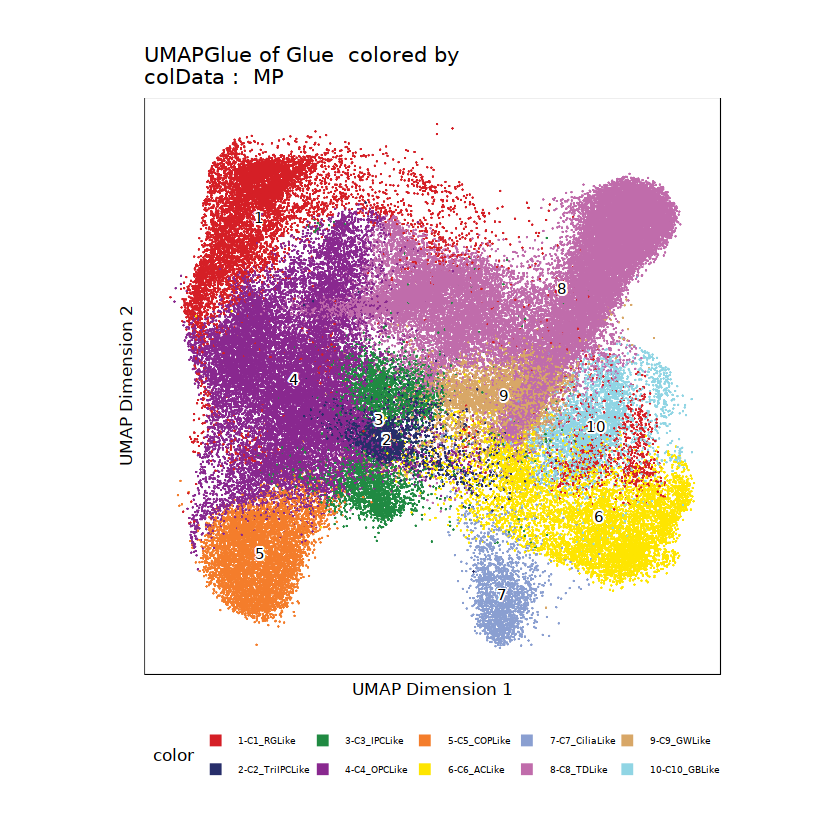

In [25]:
plotEmbedding(ArchRProj = malignant, colorBy = "cellColData", name = "MP", embedding = "UMAPGlue")

In [26]:
rm(adata)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,10695568,571.3,16908015,903.0,16908015,903.0
Vcells,89313610,681.5,237870543,1814.9,237855798,1814.7


In [28]:
saveArchRProject(ArchRProj = malignant, outputDirectory = "./ArchR_malignant_FINAL/")

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/archr/ArchR_malignant_FINAL 
samples(21): multiome_P-1709_S-1709 multiome_P-1701_S-1701 ...
  atac_P-2687_S-2688 atac_P-6255_S-8500
sampleColData names(1): ArrowFiles
cellColData names(21): Sample TSSEnrichment ... FRIP MPv2
numberOfCells(1): 83921
medianTSS(1): 8.532
medianFrags(1): 11219

In [4]:
malignant <- loadArchRProject('./ArchR_malignant_FINAL/')
malignant

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

class: ArchRProject 
outputDirectory: /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/archr/ArchR_malignant_FINAL 
samples(21): multiome_P-1709_S-1709 multiome_P-1701_S-1701 ...
  atac_P-2687_S-2688 atac_P-6255_S-8500
sampleColData names(1): ArrowFiles
cellColData names(21): Sample TSSEnrichment ... FRIP MPv2
numberOfCells(1): 83921
medianTSS(1): 8.532
medianFrags(1): 11219

In [6]:
markersPeaks_10k <- getMarkerFeatures(
    ArchRProj = malignant, 
    useMatrix = "PeakMatrix", 
    groupBy = "MP",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon",
     maxCells = 10000
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-c7314c23c519-Date-2024-09-12_Time-20-14-40.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2024-09-12 20:14:41 : Matching Known Biases, 0.017 mins elapsed.

###########
2024-09-12 20:18:17 : Completed Pairwise Tests, 3.617 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-c7314c23c519-Date-2024-09-12_Time-20-14-40.log



In [8]:
heatmapPeaks <- markerHeatmap(
  seMarker = markersPeaks_10k, 
  cutOff = "FDR <= 0.1 & Log2FC >= 0.5",
  transpose = TRUE
)

Warning message:
“'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated")”
ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-3e556a3d4bdafb-Date-2024-09-12_Time-14-30-24.log
If there is an issue, please report to github with logFile!

Identified 283043 markers!



  [1] "chr1:902041-902541"   "chr1:1031275-1031775" "chr1:1331806-1332306"
  [4] "chr1:1337648-1338148" "chr1:1827336-1827836" "chr1:1846414-1846914"
  [7] "chr1:2050680-2051180" "chr1:2126282-2126782" "chr1:2132155-2132655"
 [10] "chr1:2133971-2134471" "chr1:2205328-2205828" "chr1:2420212-2420712"
 [13] "chr1:2461788-2462288" "chr1:2524137-2524637" "chr1:2612254-2612754"
 [16] "chr1:911464-911964"   "chr1:943716-944216"   "chr1:1001162-1001662"
 [19] "chr1:1300067-1300567" "chr1:1304608-1305108" "chr1:1889323-1889823"
 [22] "chr1:2060618-2061118" "chr1:2225849-2226349" "chr1:2437972-2438472"
 [25] "chr1:2513458-2513958" "chr1:2585318-2585818" "chr1:3216728-3217228"
 [28] "chr1:3315769-3316269" "chr1:3316333-3316833" "chr1:3593314-3593814"
 [31] "chr1:1969158-1969658" "chr1:2443197-2443697" "chr1:2463334-2463834"
 [34] "chr1:2466520-2467020" "chr1:2474372-2474872" "chr1:2911181-2911681"
 [37] "chr1:3212502-3213002" "chr1:3402201-3402701" "chr1:3820967-3821467"
 [40] "chr1:4366576-43670

Adding Annotations..

Preparing Main Heatmap..

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-3e556a3d4bdafb-Date-2024-09-12_Time-14-30-24.log



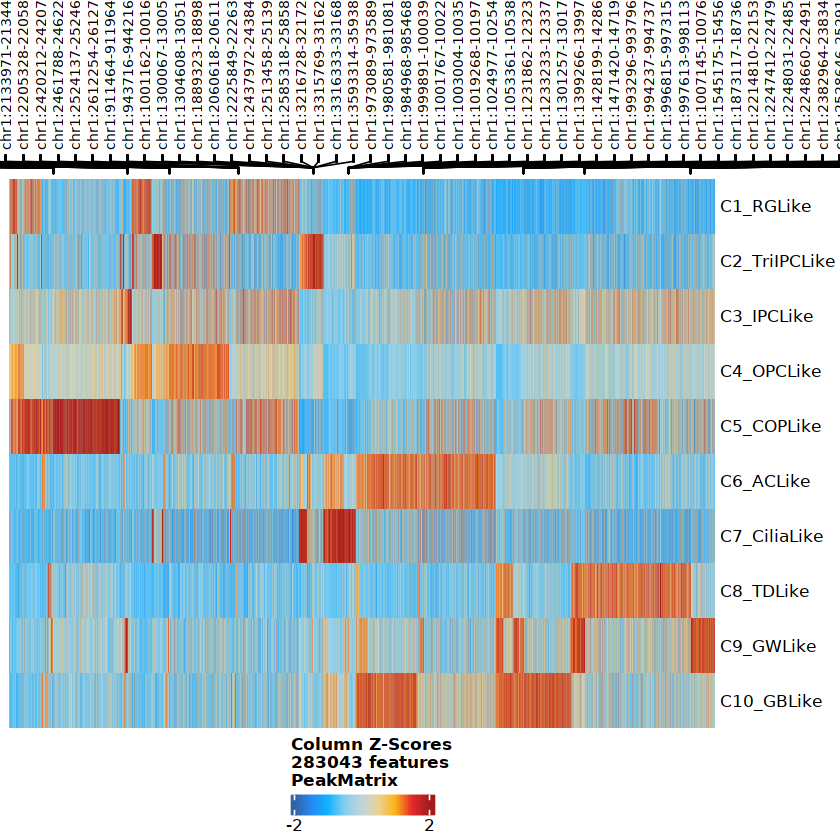

In [9]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [8]:
library(data.table)
library(GenomicRanges)
library(future)
library(future.apply)

# Define the directory containing your .tsv.gz files
tsv_dir <- "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/pycistopic_fetal/pseudobulk_bed_files/glial"

# List your .tsv.gz files
tsv_files <- list.files(tsv_dir, pattern = "*.tsv.gz", full.names = TRUE)

# Create a named list, removing the directory and extension
CustomPeaks <- setNames(tsv_files, sub(".*/(.*).fragments.tsv.gz$", "\\1", tsv_files))

# Plan to use multiple cores
plan(multisession, workers = 48)

# Parallel file processing
CustomPeaksGR <- future_lapply(CustomPeaks, function(tsv_file) {
  df <- fread(cmd = paste("zcat", tsv_file), col.names = c("chr", "start", "end", "barcode", "score"), nThread = 48)
  df[, name := paste0(chr, ":", start, "-", end)]
  df[, strand := "+"]
  df[, barcode := NULL]
  gr <- makeGRangesFromDataFrame(df, keep.extra.columns = TRUE)
  return(gr)
})

In [9]:
malignant <- addPeakAnnotations(ArchRProj = malignant, regions = CustomPeaksGR, name = "fetal")

ArchR logging to : ArchRLogs/ArchR-addPeakAnnotations-19b4be7e8f269c-Date-2024-09-11_Time-16-45-37.log
If there is an issue, please report to github with logFile!

2024-09-11 16:48:54 : Creating Peak Overlap Matrix, 3.288 mins elapsed.

2024-09-11 16:50:33 : All Regions Overlap at least 1 peak!, 4.933 mins elapsed.



In [10]:
enrichRegions <- peakAnnoEnrichment(
    seMarker = markersPeaks_10k,
    ArchRProj = malignant,
    peakAnnotation = "fetal",
    cutOff = "FDR <= 0.2 & Log2FC >= 0.25"
  )

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-19b4be2e740fb4-Date-2024-09-11_Time-16-51-45.log
If there is an issue, please report to github with logFile!

2024-09-11 16:52:06 : Computing Enrichments 1 of 10, 0.356 mins elapsed.

2024-09-11 16:52:07 : Computing Enrichments 2 of 10, 0.361 mins elapsed.

2024-09-11 16:52:07 : Computing Enrichments 3 of 10, 0.365 mins elapsed.

2024-09-11 16:52:07 : Computing Enrichments 4 of 10, 0.369 mins elapsed.

2024-09-11 16:52:07 : Computing Enrichments 5 of 10, 0.373 mins elapsed.

2024-09-11 16:52:08 : Computing Enrichments 6 of 10, 0.378 mins elapsed.

2024-09-11 16:52:08 : Computing Enrichments 7 of 10, 0.382 mins elapsed.

2024-09-11 16:52:08 : Computing Enrichments 8 of 10, 0.386 mins elapsed.

2024-09-11 16:52:08 : Computing Enrichments 9 of 10, 0.391 mins elapsed.

2024-09-11 16:52:09 : Computing Enrichments 10 of 10, 0.395 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-19b4be2e740fb4-Date-2024-09-11

In [11]:
heatmapRegions <- plotEnrichHeatmap(enrichRegions, n = 135, transpose = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-19b4be2d055c2-Date-2024-09-11_Time-16-52-09.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



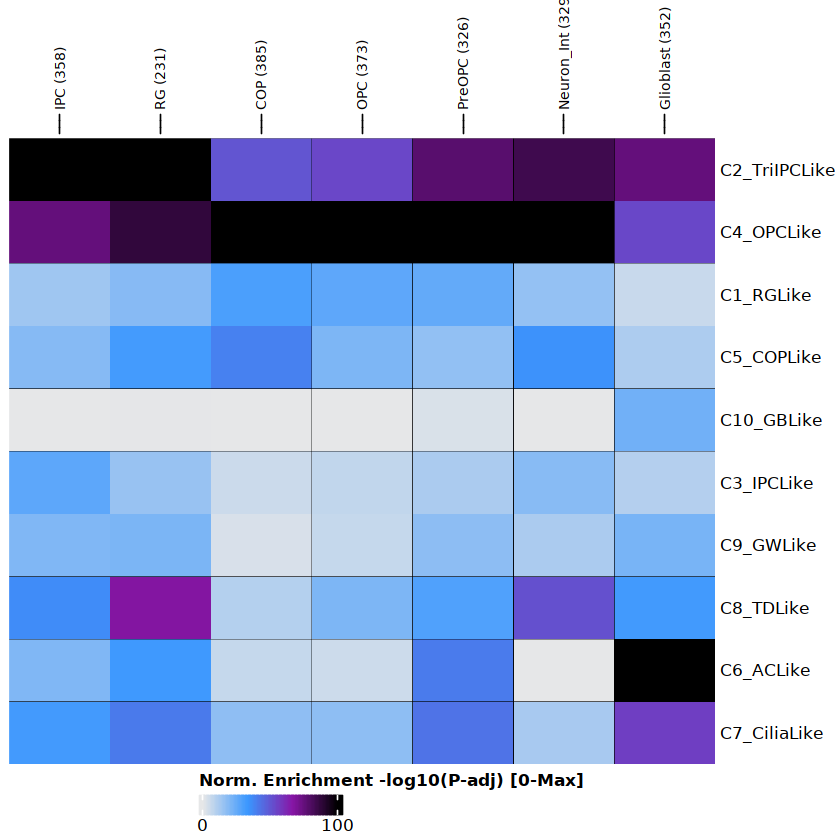

In [12]:
ComplexHeatmap::draw(heatmapRegions, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [13]:
heatmapRegions <- plotEnrichHeatmap(enrichRegions, n = 135, transpose = TRUE,
                                   clusterCols = FALSE,
                                 binaryClusterRows = TRUE,
                                   rastr = FALSE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-19b4be5452b796-Date-2024-09-11_Time-16-54-26.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



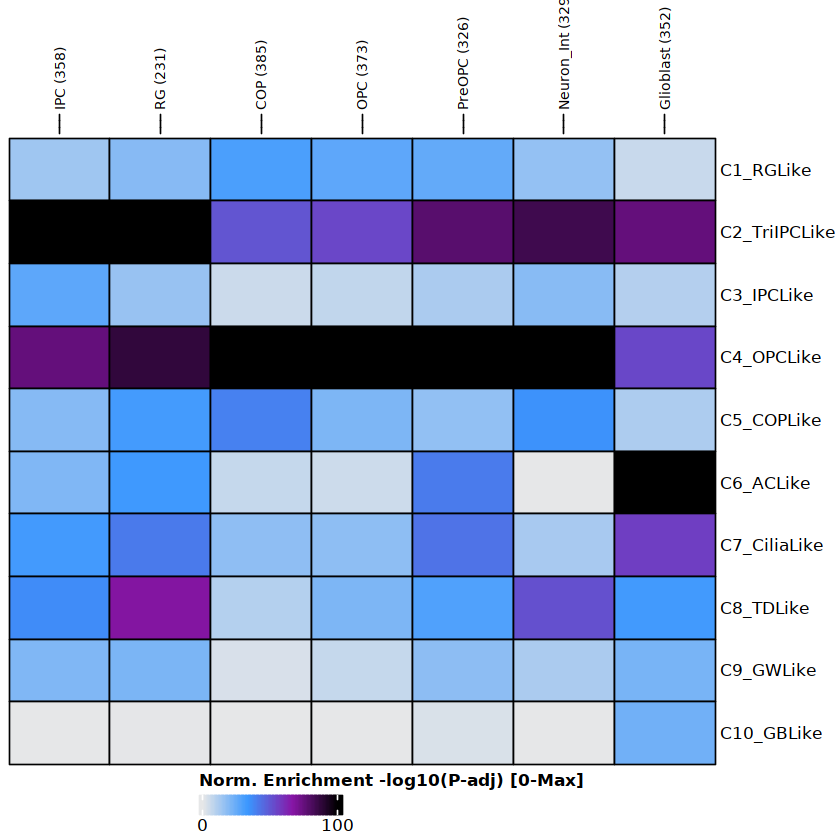

In [14]:
ComplexHeatmap::draw(heatmapRegions, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [15]:
plotPDF(heatmapRegions, name = "Mannens-Enriched-Marker-Heatmap", width = 5, height = 6, 
        ArchRProj = malignant, addDOC = FALSE)

Plotting ComplexHeatmap!

